# Classical Linearization Strategies for Nonlinear ODEs and Their Connection to VQLS

In this notebook, we study different ways of transforming a nonlinear ordinary differential equation into linear algebra problems.

The test problem is

$$
\frac{d^2 x}{dt^2}=x-x^2.
$$

Introducing $y=\frac{dx}{dt}$, we rewrite the system as

$$
\frac{dx}{dt}=y,
$$

$$
\frac{dy}{dt}=x-x^2.
$$

The purpose of this notebook is to compare several classical strategies for treating the nonlinear term $x^2$. These include:

1. Carleman linearization,
2. an auxiliary-variable linearization method (AVL),
3. a reduced-dimensional linear-system method (reduced LS),
4. Newton iteration applied to an implicit time-discretized system.

The broader motivation is hybrid quantum algorithms for nonlinear differential equations. Once a nonlinear problem is reduced to one or more linear systems of the form

$$
A X = b,
$$

a quantum linear solver such as VQLS can in principle be used as the inner linear-system solver.

In [12]:
#Packages required
import numpy as np
import matplotlib.pyplot as plt
from math import comb

from scipy.integrate import solve_ivp
from scipy.linalg import expm
import pandas as pd


## High-Accuracy Reference Solution

We first compute a high-accuracy numerical reference solution using `solve_ivp`. This reference solution is used to evaluate the accuracy of the different linearization and time-stepping methods.

Although we call this the reference solution, it is not an analytic exact solution. It is a highly accurate numerical solution computed with tight tolerances.

In [3]:
def rhs_nonlinear(t, u):
    x, y = u
    return np.array([y, x - x**2], dtype=float)

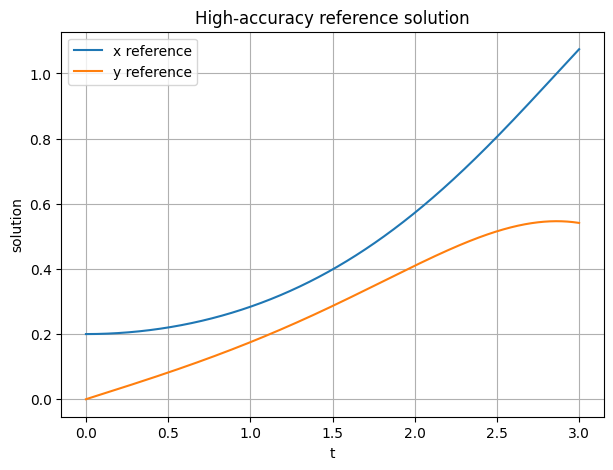

In [4]:
#High accuracy Solution for the problem
#initial conditions
x0 = 0.2
y0 = 0.0
u0 = np.array([x0, y0], dtype=float)

T = 3.0
t_eval = np.linspace(0.0, T, 2000)

# ----------------------------
sol_ref = solve_ivp(
    rhs_nonlinear, (0.0, T), u0,
    t_eval=t_eval, rtol=1e-12, atol=1e-14, method="DOP853"
)

x_ref = sol_ref.y[0]
y_ref = sol_ref.y[1]

plt.figure(figsize=(7,5))
plt.plot(t_eval, x_ref, label="x reference")
plt.plot(t_eval, y_ref, label="y reference")
plt.xlabel("t")
plt.ylabel("solution")
plt.title("High-accuracy reference solution")
plt.legend()
plt.grid(True)
plt.show()


## Method A: Carleman Linearization

Carleman linearization converts a nonlinear polynomial system into an infinite-dimensional linear system by introducing monomials of the dynamical variables.

For the system

$$
\dot{x}=y,
$$

$$
\dot{y}=x-x^2,
$$

We introduce monomials
$
z_{pq}=x^p y^q.
$.
Using the chain rule,

$$
\frac{d}{dt}(x^p y^q) =
p x^{p-1}y^q \dot{x}
+
q x^p y^{q-1}\dot{y}.
$$

Substituting $\dot{x}=y$ and $\dot{y}=x-x^2$, we obtain

$$
\frac{d}{dt}(x^p y^q) = p x^{p-1}y^{q+1}
+
q x^{p+1}y^{q-1}
-
q x^{p+2}y^{q-1}.
$$

This gives a linear system for the lifted variables ($z_{pq}$), but the full system is infinite-dimensional. In practice, we truncate the monomial basis to total degree $p+q \leq P$. After truncation, we obtain a finite-dimensional approximate linear system

$$
\dot{z}=Kz.
$$

This linear system can then be discretized and solved step by step.

In [5]:
#Carleman Linearization Method
def carleman_basis_2d(P):
    basis = []
    for d in range(1, P + 1):          
        for p in range(d, -1, -1):
            q = d - p
            basis.append((p, q))
    index = {pq: i for i, pq in enumerate(basis)}
    return basis, index

def build_carleman_K(P):
    basis, idx = carleman_basis_2d(P)
    n = len(basis)
    K = np.zeros((n, n), dtype=float)

    for (p, q) in basis:
        row = idx[(p, q)]

        # Term A: p * x^{p-1} y^{q+1}
        if p > 0:
            pqA = (p - 1, q + 1)
            if (pqA in idx) and ((pqA[0] + pqA[1]) <= P):
                K[row, idx[pqA]] += p

        # Term B: q * x^{p+1} y^{q-1}
        if q > 0:
            pqB = (p + 1, q - 1)
            if (pqB in idx) and ((pqB[0] + pqB[1]) <= P):
                K[row, idx[pqB]] += q

        # Term C: - q * x^{p+2} y^{q-1}
        if q > 0:
            pqC = (p + 2, q - 1)
            # This is the degree-raising term; included only if within truncation
            if (pqC in idx) and ((pqC[0] + pqC[1]) <= P):
                K[row, idx[pqC]] -= q

    return K, basis, idx

def lift_initial_state(u0, basis):
    x0, y0 = u0
    z0 = np.array([ (x0**p) * (y0**q) for (p,q) in basis ], dtype=float)
    return z0

def extract_xy_from_z(z, idx):
    x = z[idx[(1,0)]]
    y = z[idx[(0,1)]]
    return x, y


In [6]:
def solve_carleman_implicit(P, u0, t_eval):
    """
    Solve the Carleman-linearized system using implicit Euler.

    Parameters
    ----------
    P : int
        Truncation order.
    u0 : array-like
        Initial condition [x0, y0].
    t_eval : array
        Time grid.

    Returns
    -------
    x_carl, y_carl, K, basis, idx
    """
    K, basis, idx = build_carleman_K(P)
    z0 = lift_initial_state(u0, basis)

    h = t_eval[1] - t_eval[0]
    I = np.eye(K.shape[0])
    A = I - h * K

    Z = np.zeros((len(basis), len(t_eval)))
    Z[:, 0] = z0

    for n in range(len(t_eval) - 1):
        Z[:, n+1] = np.linalg.solve(A, Z[:, n])

    x_carl = Z[idx[(1,0)], :]
    y_carl = Z[idx[(0,1)], :]

    return x_carl, y_carl, K, basis, idx

In [8]:
#Error Calculation
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

In [9]:
#Running multiple truncation orders
P_list = [2, 3, 4, 5, 6]

carleman_results = {}

for P in P_list:
    x_carl, y_carl, K, basis, idx = solve_carleman_implicit(P, u0, t_eval)
    carleman_results[P] = {
        "x": x_carl,
        "y": y_carl,
        "K": K,
        "basis": basis,
        "idx": idx,
        "dim": len(basis),
        "rmse_x": rmse(x_carl, x_ref),
        "rmse_y": rmse(y_carl, y_ref),
        "condition_number": np.linalg.cond(np.eye(K.shape[0]) - (t_eval[1]-t_eval[0]) * K)
    }

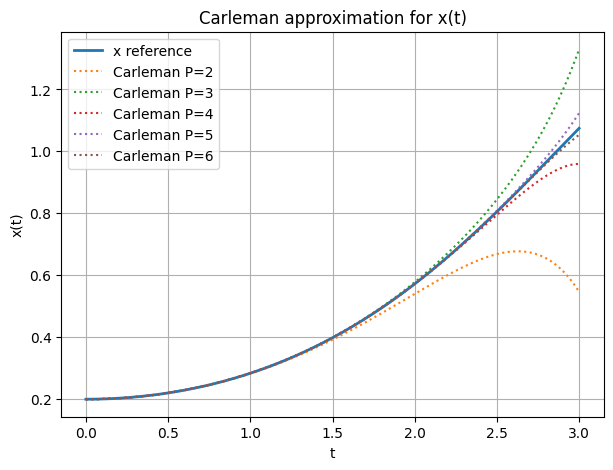

In [10]:
#Plot results
plt.figure(figsize=(7,5))
plt.plot(t_eval, x_ref, label="x reference", linewidth=2)

for P in P_list:
    plt.plot(t_eval, carleman_results[P]["x"], ":", label=f"Carleman P={P}")

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Carleman approximation for x(t)")
plt.legend()
plt.grid(True)
plt.show()



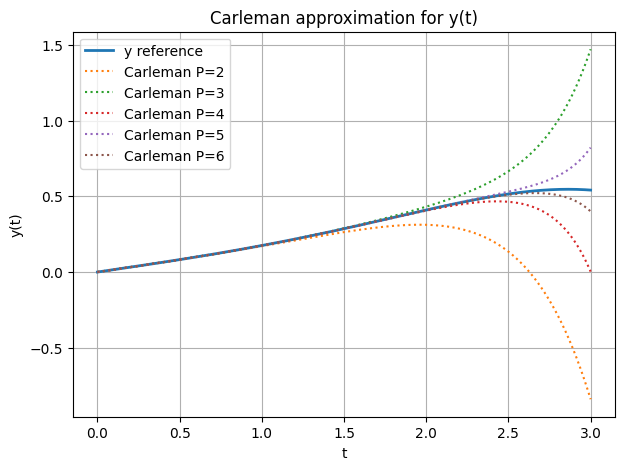

In [11]:
#Plot results
plt.figure(figsize=(7,5))
plt.plot(t_eval, y_ref, label="y reference", linewidth=2)

for P in P_list:
    plt.plot(t_eval, carleman_results[P]["y"], ":", label=f"Carleman P={P}")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Carleman approximation for y(t)")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
#Summary of the results
carleman_summary = pd.DataFrame([
    {
        "P": P,
        "dimension": carleman_results[P]["dim"],
        "RMSE x": carleman_results[P]["rmse_x"],
        "RMSE y": carleman_results[P]["rmse_y"],
        "condition number": carleman_results[P]["condition_number"],
    }
    for P in P_list
])

carleman_summary

,P,dimension,RMSE x,RMSE y,condition number
0,2,5,0.131910,0.352743,1.006504
1,3,9,0.054314,0.200308,1.010410
2,4,14,0.021557,0.102392,1.014591
3,5,20,0.008426,0.048097,1.018919
4,6,27,0.003266,0.022431,1.023364


Increasing the Carleman truncation order increases the dimension of the lifted linear system. In principle, a larger \(P\) retains more nonlinear information. However, higher truncation order also increases the matrix size and can lead to numerical instability or poor conditioning. This illustrates the main trade-off of Carleman linearization.

## Method B: Auxiliary-Variable Linearization (AVL) Method

This method discretizes the nonlinear ODE using explicit Euler and writes each time step as a local algebraic linear system.

The nonlinear term ($x_n^2$) is included as an auxiliary component of the solution vector. For the system

$$
x_{n+1}=x_n+h y_n,
$$

$$
y_{n+1}=y_n+h(x_n-x_n^2),
$$

We introduce an auxiliary variable
$
s_n=x_n^2.
$
.Then the local unknown vector is

$$
X_n =
\begin{pmatrix}
x_n\\
y_n\\
x_{n+1}\\
y_{n+1}\\
s_n
\end{pmatrix}.
$$

At each time step, $(s_n=x_n^2)$ is evaluated from the current state and included in the linear system.

This is useful for VQLS because each time step produces a linear system

\begin{align}
    \begin{pmatrix} 1 & 0 & 0 & 0 & 0\\ 0 & 1 & 0 & 0 & 0\\-1&-h&1&0 & 0\\-h & -1 & 0 &1 & h \\ 0 & 0 & 0 & 0 & 1 \end{pmatrix} 
    \begin{pmatrix} x_n \\ y_n \\ x_{n+1} \\ y_{n+1} \\ x_n^2\end{pmatrix} & = \begin{pmatrix} x_n \\ y_n \\ 0 \\ 0 \\ x_n^2\end{pmatrix} \\
    A \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ X_n  \ \ \ \ & = \ \ \ \ \ \ b_n
\end{align}

A quantum linear solver could be used to solve this system at each step.

For an actual quantum-state encoding, a 5-dimensional system would usually be padded to dimension $(8=2^3)$. The $5$-dimensional version is shown here only to illustrate the algebraic structure.

In [15]:
def solve_auxiliary_ls_method(t_eval, x0, y0):
    h = t_eval[1] - t_eval[0]

    A = np.eye(5)
    A[2,0] = -1.0
    A[2,1] = -h
    A[3,0] = -h
    A[3,1] = -1.0
    A[3,4] = h

    b = np.array([x0, y0, 0.0, 0.0, x0**2], dtype=float)

    x = np.zeros(len(t_eval))
    y = np.zeros(len(t_eval))

    x[0] = x0
    y[0] = y0

    for n in range(1, len(t_eval)):
        z = np.linalg.solve(A, b)

        x_next = z[2]
        y_next = z[3]

        x[n] = x_next
        y[n] = y_next

        b[0] = x_next
        b[1] = y_next
        b[4] = x_next**2

    return x, y, A

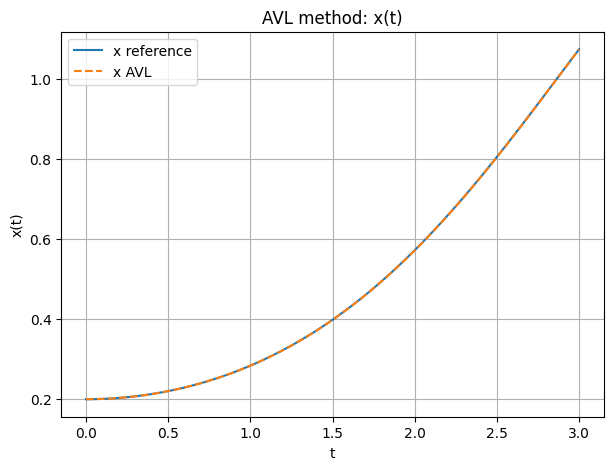

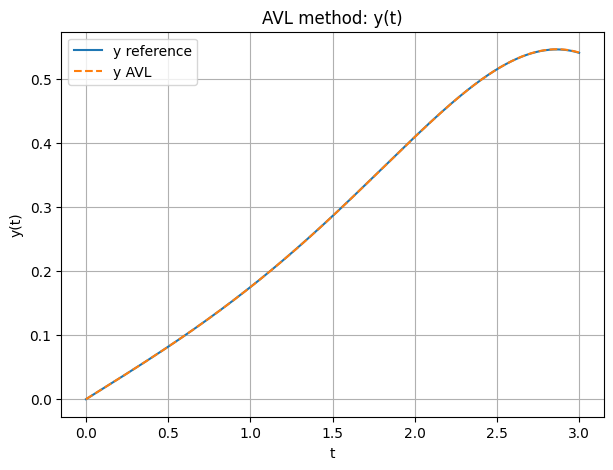

RMSE x: AVL vs reference = 0.00035942098801977146
RMSE y: AVL vs reference = 0.00013027011514061748
Condition number of AVL matrix = 2.6215513566074544


In [17]:
x_aux, y_aux, A_aux = solve_auxiliary_ls_method(t_eval, x0, y0)

plt.figure(figsize=(7,5))
plt.plot(t_eval, x_ref, label="x reference")
plt.plot(t_eval, x_aux, "--", label="x AVL")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("AVL method: x(t)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(t_eval, y_ref, label="y reference")
plt.plot(t_eval, y_aux, "--", label="y AVL")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("AVL method: y(t)")
plt.legend()
plt.grid(True)
plt.show()

print("RMSE x: AVL vs reference =", rmse(x_aux, x_ref))
print("RMSE y: AVL vs reference =", rmse(y_aux, y_ref))
print("Condition number of AVL matrix =", np.linalg.cond(A_aux))

## Method C: Reduced-Dimensional Explicit Local Linear-System Method

The previous method includes ($x_n^2$) as an auxiliary component of the unknown vector. However, because $x_n$ is already known at the beginning of the time step, the nonlinear term ($x_n^2$) can instead be evaluated directly and moved into the right-hand side.

This gives a smaller local linear system. The unknown vector is

$$
X_n =
\begin{pmatrix}
x_n\\
y_n\\
x_{n+1}\\
y_{n+1}
\end{pmatrix}.
$$

The explicit Euler update is

$$
x_{n+1}=x_n+h y_n,
$$

$$
y_{n+1}=y_n+h x_n-hx_n^2.
$$

The nonlinear contribution ($-h x_n^2$) is included in the right-hand side vector. This avoids introducing an auxiliary variable and reduces the system dimension from $5$ to $4$. And, the matrix system becomes

\begin{align}
    \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\-1&-h&1&0 \\-h & -1 & 0 &1 \end{pmatrix} 
    \begin{pmatrix} x_n \\ y_n \\ x_{n+1} \\ y_{n+1} \end{pmatrix} & = \begin{pmatrix} x_n \\ y_n \\ 0 \\ -h x_n^2 \end{pmatrix} \\
    A \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ X_n  \ \ \ \ & = \ \ \ \ \ \ b_n
\end{align}

This is more efficient for VQLS because a 4-dimensional system can be encoded directly using two qubits.

In [18]:
def solve_reduced_explicit_ls_method(t_eval, x0, y0):
    h = t_eval[1] - t_eval[0]

    A = np.eye(4)
    A[2,0] = -1.0
    A[2,1] = -h
    A[3,0] = -h
    A[3,1] = -1.0

    b = np.array([x0, y0, 0.0, -h * x0**2], dtype=float)

    x = np.zeros(len(t_eval))
    y = np.zeros(len(t_eval))

    x[0] = x0
    y[0] = y0

    for n in range(1, len(t_eval)):
        z = np.linalg.solve(A, b)

        x_next = z[2]
        y_next = z[3]

        x[n] = x_next
        y[n] = y_next

        b[0] = x_next
        b[1] = y_next
        b[3] = -h * x_next**2

    return x, y, A

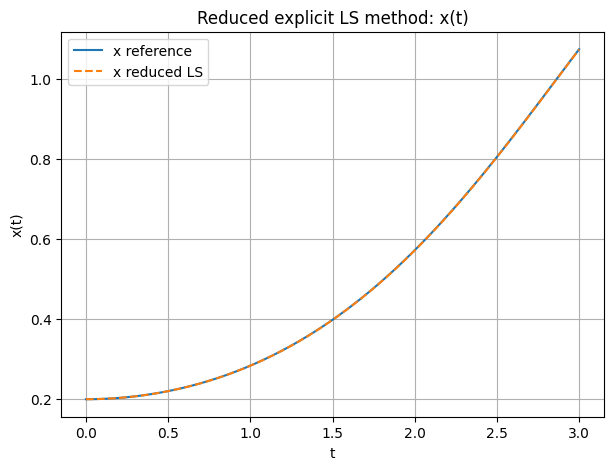

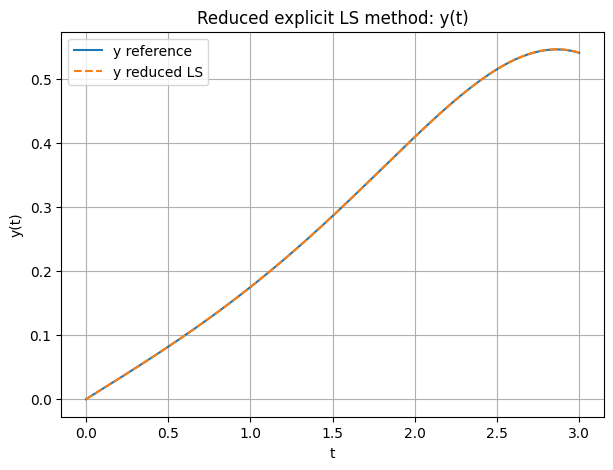

RMSE x: reduced LS vs reference = 0.0003594209880198713
RMSE y: reduced LS vs reference = 0.00013027011514068538
Condition number of reduced LS matrix = 2.6215500384727046


In [19]:
x_red, y_red, A_red = solve_reduced_explicit_ls_method(t_eval, x0, y0)

plt.figure(figsize=(7,5))
plt.plot(t_eval, x_ref, label="x reference")
plt.plot(t_eval, x_red, "--", label="x reduced LS")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Reduced explicit LS method: x(t)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(t_eval, y_ref, label="y reference")
plt.plot(t_eval, y_red, "--", label="y reduced LS")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Reduced explicit LS method: y(t)")
plt.legend()
plt.grid(True)
plt.show()

print("RMSE x: reduced LS vs reference =", rmse(x_red, x_ref))
print("RMSE y: reduced LS vs reference =", rmse(y_red, y_ref))
print("Condition number of reduced LS matrix =", np.linalg.cond(A_red))

## Method D: Newton Iteration for an Implicit Time Step

The previous local linear-system methods used explicit Euler, where the nonlinear term is evaluated at the known current state ($x_n$). Another important approach is to use an implicit discretization.

For the system

$$
\dot{x}=y,
$$

$$
\dot{y}=x-x^2,
$$

Implicit Euler gives

$$
x_{n+1}=x_n+h y_{n+1},
$$

$$
y_{n+1}=y_n+h(x_{n+1}-x_{n+1}^2).
$$

This is no longer a linear system because the unknown $x_{n+1}$ appears quadratically.

Define
$$
z =
\begin{pmatrix}
x_{n+1}\\
y_{n+1}
\end{pmatrix}.
$$

Then, the nonlinear system at each time step is

$$
F(z)=0,
$$

where

$$
F_1(z)=x_{n+1}-x_n-hy_{n+1},
$$

$$
F_2(z)=y_{n+1}-y_n-h(x_{n+1}-x_{n+1}^2).
$$

Newton's method solves this nonlinear algebraic system iteratively. Starting from a guess $z^{(k)}$, we solve the linear system

$$
J(z^{(k)})\Delta z^{(k)}=-F(z^{(k)}),
$$

and update

$$
z^{(k+1)}=z^{(k)}+\Delta z^{(k)}.
$$

Here, $J$ is the Jacobian matrix of $F$. This is important for quantum algorithms because each Newton iteration requires solving a linear system. In a hybrid quantum version, VQLS could be used as the inner linear solver for the Newton correction equation.

In [20]:
#one implicit Euler step for the nonlinear system
#return next time step values
def newton_step_implicit_euler(xn, yn, h, tol=1e-12, max_iter=20):
    # Explicit Euler prediction as initial guess
    x_guess = xn + h * yn
    y_guess = yn + h * (xn - xn**2)

    z = np.array([x_guess, y_guess], dtype=float)

    for k in range(max_iter):
        x, y = z

        # Nonlinear residual F(z)
        F = np.array([
            x - xn - h * y,
            y - yn - h * (x - x**2)
        ], dtype=float)

        # Jacobian J = dF/dz
        J = np.array([
            [1.0, -h],
            [-h * (1.0 - 2.0*x), 1.0]
        ], dtype=float)

        # Newton correction
        delta = np.linalg.solve(J, -F)

        z = z + delta

        if np.linalg.norm(delta) < tol:
            break

    final_F = np.array([
        z[0] - xn - h * z[1],
        z[1] - yn - h * (z[0] - z[0]**2)
    ], dtype=float)

    final_residual = np.linalg.norm(final_F)

    return z[0], z[1], k + 1, final_residual

In [21]:
#Function for solving all time steps
def solve_newton_implicit_euler(t_eval, x0, y0, tol=1e-12, max_iter=20):
    h = t_eval[1] - t_eval[0]

    x = np.zeros(len(t_eval))
    y = np.zeros(len(t_eval))
    newton_iters = np.zeros(len(t_eval)-1, dtype=int)
    newton_residuals = np.zeros(len(t_eval)-1)

    x[0] = x0
    y[0] = y0

    for n in range(len(t_eval)-1):
        x_next, y_next, n_iter, res = newton_step_implicit_euler(
            x[n], y[n], h, tol=tol, max_iter=max_iter
        )

        x[n+1] = x_next
        y[n+1] = y_next
        newton_iters[n] = n_iter
        newton_residuals[n] = res

    return x, y, newton_iters, newton_residuals

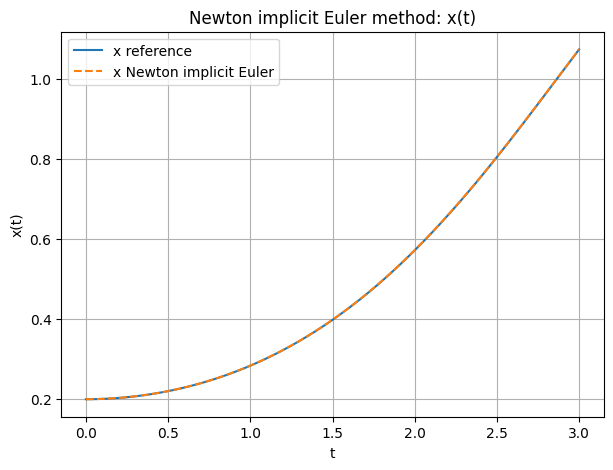

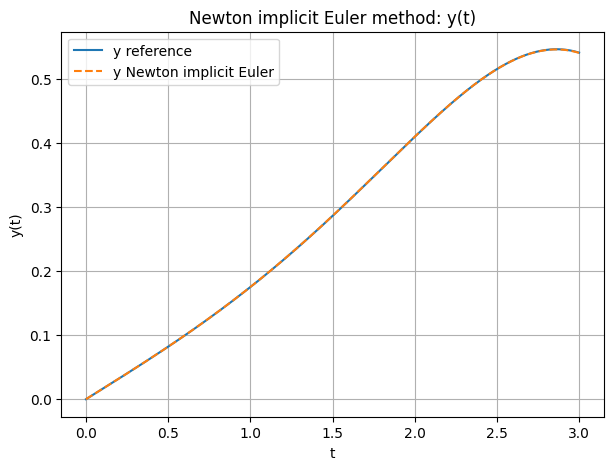

RMSE x: Newton implicit Euler vs reference = 0.00035935161585919214
RMSE y: Newton implicit Euler vs reference = 0.00013063038761864222
Average Newton iterations per step = 2.0
Maximum Newton iterations in one step = 2
Maximum Newton residual = 1.187581394111626e-16


In [22]:
x_newton, y_newton, newton_iters, newton_residuals = solve_newton_implicit_euler(
    t_eval, x0, y0, tol=1e-12, max_iter=20
)

plt.figure(figsize=(7,5))
plt.plot(t_eval, x_ref, label="x reference")
plt.plot(t_eval, x_newton, "--", label="x Newton implicit Euler")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Newton implicit Euler method: x(t)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(t_eval, y_ref, label="y reference")
plt.plot(t_eval, y_newton, "--", label="y Newton implicit Euler")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Newton implicit Euler method: y(t)")
plt.legend()
plt.grid(True)
plt.show()

print("RMSE x: Newton implicit Euler vs reference =", rmse(x_newton, x_ref))
print("RMSE y: Newton implicit Euler vs reference =", rmse(y_newton, y_ref))
print("Average Newton iterations per step =", np.mean(newton_iters))
print("Maximum Newton iterations in one step =", np.max(newton_iters))
print("Maximum Newton residual =", np.max(newton_residuals))

### Connection to VQLS

At each Newton iteration, the correction $\Delta z^{(k)}$ is obtained by solving

$$
J(z^{(k)})\Delta z^{(k)}=-F(z^{(k)}).
$$

This is a linear system. Therefore, a hybrid quantum version of Newton's method could use VQLS to solve the Newton correction equation.

The outer Newton loop would remain classical, while VQLS would act as the inner linear solver. This gives the structure:

$$
\text{nonlinear ODE}
\rightarrow
\text{implicit time discretization}
\rightarrow
\text{Newton linearization}
\rightarrow
\text{linear system}
\rightarrow
\text{VQLS}.
$$

This approach is more sophisticated than the explicit local linear-system method, but it can also be more expensive because each time step may require several linear solves.

## Comparison of the methods

In [26]:
comparison_rows = []

comparison_rows.append({
    "method": "AVL",
    "dimension": 5,
    "RMSE x": rmse(x_aux, x_ref),
    "RMSE y": rmse(y_aux, y_ref),
    "notes": "Explicit Euler; nonlinear term as auxiliary variable"
})

comparison_rows.append({
    "method": "Reduced LS",
    "dimension": 4,
    "RMSE x": rmse(x_red, x_ref),
    "RMSE y": rmse(y_red, y_ref),
    "notes": "Explicit Euler; nonlinear term moved to RHS"
})

comparison_rows.append({
    "method": "Newton's Iteration",
    "dimension": 2,
    "RMSE x": rmse(x_newton, x_ref),
    "RMSE y": rmse(y_newton, y_ref),
    "notes": "Implicit Euler; linear solve per Newton iteration"
})

for P in P_list:
    comparison_rows.append({
        "method": f"Carleman P={P}",
        "dimension": carleman_results[P]["dim"],
        "RMSE x": carleman_results[P]["rmse_x"],
        "RMSE y": carleman_results[P]["rmse_y"],
        "notes": "Lifted linear system"
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,method,dimension,RMSE x,RMSE y,notes
0,AVL,5,0.000359,0.000130,Explicit Euler; nonlinear term as auxiliary va...
1,Reduced LS,4,0.000359,0.000130,Explicit Euler; nonlinear term moved to RHS
2,Newton's Iteration,2,0.000359,0.000131,Implicit Euler; linear solve per Newton iteration
3,Carleman P=2,5,0.131910,0.352743,Lifted linear system
4,Carleman P=3,9,0.054314,0.200308,Lifted linear system
5,Carleman P=4,14,0.021557,0.102392,Lifted linear system
6,Carleman P=5,20,0.008426,0.048097,Lifted linear system
7,Carleman P=6,27,0.003266,0.022431,Lifted linear system


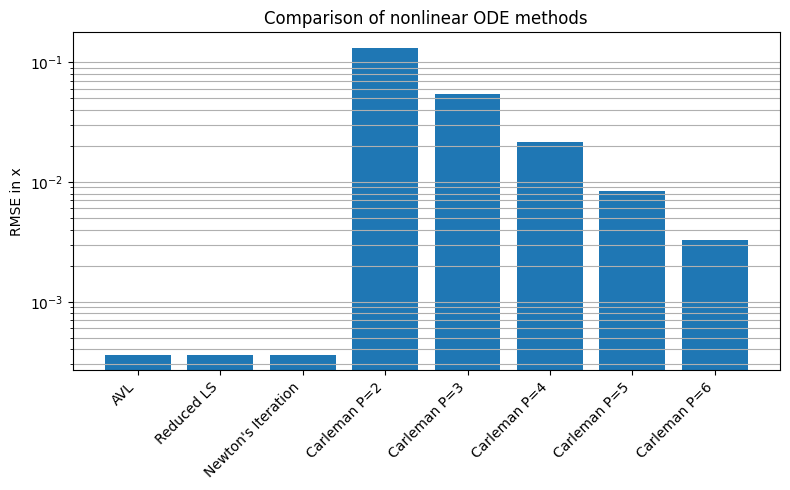

In [27]:
plt.figure(figsize=(8,5))
plt.bar(comparison_df["method"], comparison_df["RMSE x"])
plt.yscale("log")
plt.ylabel("RMSE in x")
plt.title("Comparison of nonlinear ODE methods")
plt.xticks(rotation=45, ha="right")
plt.grid(True, which="both", axis="y")
plt.tight_layout()
plt.show()

## Summary and Interpretation

In this notebook, we compared several ways of treating a nonlinear ODE in a form relevant for hybrid quantum linear solvers.

The main observations are:

1. **Carleman linearization** converts the nonlinear system into a larger linear system by lifting the dynamics to monomials. This is systematic, but the dimension grows rapidly with truncation order.

2. **The auxiliary-variable linearization (AVL) method** rewrites each explicit Euler step as a linear system by including the nonlinear term as an auxiliary variable. This produces a linear system at every step, but the dimension may need padding for quantum-state encoding.

3. **The reduced explicit local linear-system method** moves the nonlinear term into the right-hand side. This gives a smaller linear system and is especially attractive for VQLS because the dimension is lower.

4. **Newton iteration** arises naturally from implicit time discretization. It solves a nonlinear algebraic equation at each time step by repeatedly solving linear systems involving the Jacobian. This provides a natural hybrid structure in which VQLS could be used as the inner linear solver.

Overall, the key idea is that nonlinear ODEs are not solved directly by VQLS. Instead, classical reformulation or linearization methods are used to produce linear systems. VQLS can then be inserted as a subroutine for solving those linear systems.